# Ejercicio 3 - Índices NDVI, NDWI y cianobacteria

Este cuaderno calcula, para cada combinación oficial lago-fecha, los tres
índices pedidos en el laboratorio: NDVI, NDWI y el índice de cianobacteria.
Depende de los raster crudos ya descargados (`data/raw/rasters/`, bandas
B03, B04, B08, SCL de Sentinel-2 L2A) y produce el contrato
`manifest_indices.csv` que usa el ejercicio 4.

Por defecto el cuaderno solo valida configuración y contrato sin descargar ni
calcular nada remoto, igual que el cuaderno de los ejercicios 1 y 2.

## 1. Decisión del script de cianobacteria

El catálogo de https://custom-scripts.sentinel-hub.com tiene varios scripts
relacionados con agua/algas para Sentinel-2 (NDCI L1C, Se2WaQ, Maximum Peak
Height Bloom Index, APA Script). Se eligió **CyanoLakes Chlorophyll-a L1C
(NDCI)** porque:

- Es el único nombrado explícitamente para cianobacteria, no para calidad de
  agua en general.
- Su fórmula, umbrales y máscara de agua son públicos y auditables (no es
  una caja negra): `src/evalscripts/cyano_ndci_l1c_original.js` es una copia
  textual, sin modificar, del script del catálogo.
- Usa Sentinel-2 **L1C** (reflectancia TOA), el producto para el que fue
  calibrado el polinomio de clorofila-a. Por eso **no se reproduce
  localmente sobre L2A**: se pide directamente a la Process API de
  Sentinel Hub / Copernicus Data Space el resultado numérico de ese script
  (decisión explícita del ejercicio 3.1 del enunciado).

`src/evalscripts/cyano_ndci_l1c_numeric.js` es una adaptación fiel del
script original: mismas fórmulas, mismos umbrales y mismas 9 bandas de
entrada; lo único que cambia es la salida, que deja de ser un color RGB de
visualización y pasa a ser un valor numérico FLOAT32 (`chl`), con una banda
`dataMask` que marca como válido únicamente lo que el propio script clasifica
como agua. Esto es necesario porque, como señala el enunciado, "una imagen
RGB coloreada sirve para visualizar, pero no para recuperar de forma válida
el índice promedio".

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
if not (ROOT / 'src').is_dir():
    raise RuntimeError('Abra Jupyter desde la raíz de Laboratorio 4')

sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import display

from src import indices


In [2]:
from src.config import (
    CYANO_SCRIPT,
    ESCENAS_OFICIALES,
    INDICES,
    RESOLUCION_OBJETIVO_M,
)
from src.indices import (
    compute_indices_batch,
    compute_indices_for_scene,
    prepare_indices_repository,
    request_cyano_layer,
    select_scenes,
    validate_manifest_indices,
)

print(f'Raíz del proyecto: {ROOT}')
print(f'Índices a calcular: {INDICES}')
print(f'Resolución objetivo: {RESOLUCION_OBJETIVO_M} m')


Raíz del proyecto: /Users/joel/Desktop/Lab4_Data/data-science-lab-4-datos-geoespaciales
Índices a calcular: ('ndvi', 'ndwi', 'cianobacteria')
Resolución objetivo: 10 m


## 2. Preparación local y contrato de datos

`manifest_indices.csv` nace con 66 filas (22 escenas oficiales x 3 índices)
en estado `pendiente_calculo`. Cada fila se completa únicamente cuando el
índice correspondiente se calcula y exporta con éxito.

In [3]:
summary = prepare_indices_repository()
rows = validate_manifest_indices()
manifest = pd.DataFrame(rows)

print(f"Filas del manifiesto de índices: {summary['rows']}")
display(manifest.groupby(['indice', 'quality_flag']).size().rename('n').reset_index())


Filas del manifiesto de índices: 66


,indice,quality_flag,n
0,cianobacteria,pendiente_calculo,22
1,ndvi,calculado,18
2,ndvi,cobertura_parcial_oficial,1
3,ndvi,revisar_valores_atipicos,3
4,ndwi,calculado,18
5,ndwi,cobertura_parcial_oficial,1
6,ndwi,revisar_valores_atipicos,3


## 3. Fórmulas documentadas

Las mismas fórmulas se usan en `src/indices.py`; aquí solo se muestran para
que queden visibles junto a los resultados.

In [4]:
formulas = pd.Series(
    {
        'NDVI': 'NDVI = (B08 - B04) / (B08 + B04)',
        'NDWI': 'NDWI = (B03 - B08) / (B03 + B08)',
        'Cianobacteria (NDCI)': CYANO_SCRIPT['formula_ndci'],
        'Cianobacteria (chl-a)': CYANO_SCRIPT['formula_chl'],
        'Máscara de agua del script': CYANO_SCRIPT['mascara'],
        'Unidad cianobacteria': CYANO_SCRIPT['unidad'],
        'Script fuente': CYANO_SCRIPT['url_fuente'],
    },
    name='definición',
)
formulas.to_frame()


,definición
NDVI,NDVI = (B08 - B04) / (B08 + B04)
NDWI,NDWI = (B03 - B08) / (B03 + B08)
Cianobacteria (NDCI),NDCI = (B05 - B04) / (B05 + B04)
Cianobacteria (chl-a),chl = 826.57*NDCI^3 - 176.43*NDCI^2 + 19*NDCI ...
Máscara de agua del script,Water Body Index propio del script: agua si MN...
Unidad cianobacteria,µg/L (proxy de clorofila-a; polinomio ajustado...
Script fuente,https://github.com/sentinel-hub/custom-scripts...


## 4. Escena demostrativa (una fecha)

Ya se descargaron las 22 escenas oficiales (B03, B04, B08, SCL), así
que `EJECUTAR_DEMO` queda en `True`: NDVI y NDWI se calculan con datos
reales sin necesitar credenciales. Cianobacteria todavía depende de
`SENTINEL_HUB_CLIENT_ID`/`SENTINEL_HUB_CLIENT_SECRET`, que el equipo aún no
tiene configurados; con `EJECUTAR_CYANO_REMOTO=False` esa escena
simplemente se omite para cianobacteria (queda `pendiente_calculo`) sin
bloquear NDVI/NDWI.

In [5]:
EJECUTAR_DEMO = True
EJECUTAR_CYANO_REMOTO = False

demo_scene = select_scenes('amatitlan', '2025-01-28')[0]

if EJECUTAR_DEMO:
    if EJECUTAR_CYANO_REMOTO:
        cyano_path = request_cyano_layer(demo_scene)
        print(f'Cianobacteria descargada: {cyano_path}')
    outputs = compute_indices_for_scene(demo_scene, fetch_cyano_remote=False)
    for indice, path in outputs.items():
        print(f'- {indice}: {path}')
    faltantes = sorted(set(INDICES) - set(outputs))
    if faltantes:
        print(f'Pendientes (sin insumo todavía): {faltantes}')
else:
    print('Demo omitida. Requiere raster crudos ya descargados para', demo_scene.lago, demo_scene.fecha)
    print('Cambie EJECUTAR_DEMO=True (y EJECUTAR_CYANO_REMOTO=True si falta el raster de cianobacteria).')


- ndvi: /Users/joel/Desktop/Lab4_Data/data-science-lab-4-datos-geoespaciales/data/processed/indices/amatitlan/2025-01-28/ndvi.tif
- ndwi: /Users/joel/Desktop/Lab4_Data/data-science-lab-4-datos-geoespaciales/data/processed/indices/amatitlan/2025-01-28/ndwi.tif
Pendientes (sin insumo todavía): ['cianobacteria']


## 5. Control numérico y visual de la escena demostrativa

Solo aplica si la celda anterior se ejecutó con éxito: compara los índices
exportados contra el manifiesto y muestra un mapa rápido de cada uno que
sí se haya podido calcular.

/var/folders/8w/jnkqtp012r3_c8tvsjhkkqp40000gn/T/ipykernel_19090/3090039813.py:10: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  array = dataset.read(1)


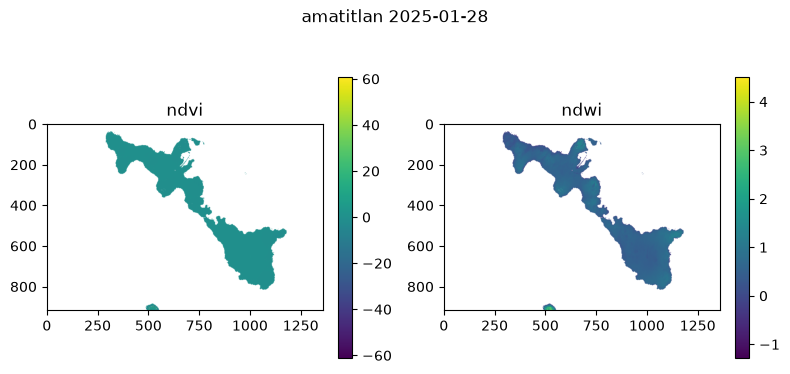

In [6]:
if EJECUTAR_DEMO:
    import matplotlib.pyplot as plt
    import rasterio

    disponibles = sorted(outputs)
    fig, axes = plt.subplots(1, len(disponibles), figsize=(4 * len(disponibles), 4), squeeze=False)
    for ax, indice in zip(axes[0], disponibles):
        path = outputs[indice]
        with rasterio.open(path) as dataset:
            array = dataset.read(1)
        im = ax.imshow(array)
        ax.set_title(indice)
        plt.colorbar(im, ax=ax, fraction=0.046)
    plt.suptitle(f"{demo_scene.lago} {demo_scene.fecha}")
    plt.tight_layout()
    plt.show()
else:
    print('Sin datos de la demo todavía.')


## 6. Cálculo del lote de 22 escenas

Ya se validó la escena demostrativa, así que `EJECUTAR_LOTE=True`: calcula
NDVI/NDWI reales para las 22 escenas oficiales. `FETCH_CYANO_REMOTO_LOTE`
queda en `False` porque las credenciales de Sentinel Hub todavía no están
configuradas; en cuanto lo estén, basta con volver a correr esta celda con
esa bandera en `True` (o `python src/indices.py compute --confirm-batch
--fetch-cyano-remote` desde la terminal) para completar las filas de
cianobacteria sin perder lo ya calculado.

In [7]:
EJECUTAR_LOTE = True
FETCH_CYANO_REMOTO_LOTE = False

if EJECUTAR_LOTE:
    resultados = compute_indices_batch(
        list(ESCENAS_OFICIALES),
        fetch_cyano_remote=FETCH_CYANO_REMOTO_LOTE,
        confirm_batch=True,
    )
    print(f'Escenas procesadas: {len(resultados)}')
    indices_por_escena = {k: sorted(v) for k, v in resultados.items()}
    print('Índices obtenidos por escena (ejemplo):', next(iter(indices_por_escena.items())))
else:
    print('Lote omitido. Cambie EJECUTAR_LOTE=True para calcular las 22 escenas.')


Escenas procesadas: 22
Índices obtenidos por escena (ejemplo): ('amatitlan_2025-01-28', ['ndvi', 'ndwi'])


## 7. Tabla de control de calidad

Mínimos, máximos, promedio y cobertura válida por producto, leídos
directamente de `manifest_indices.csv` (fuente única para el ejercicio 4,
según el contrato de la planificación de avances).

In [8]:
rows = validate_manifest_indices()
manifest = pd.DataFrame(rows)
numeric_cols = ['pixeles_validos', 'pixeles_lago', 'cobertura_valida_pct', 'frac_valores_atipicos']
manifest = manifest.assign(**{col: pd.to_numeric(manifest[col], errors='coerce') for col in numeric_cols})

resumen_calidad = (
    manifest.groupby('indice')[numeric_cols]
    .agg(['count', 'mean', 'min', 'max'])
)
display(resumen_calidad)
print('Filas por quality_flag:')
display(manifest.groupby(['indice', 'quality_flag']).size().rename('n').reset_index())
print('Escenas con advertencia (cobertura parcial oficial o valores atípicos frecuentes):')
display(manifest[manifest['quality_flag'].isin(['cobertura_parcial_oficial', 'revisar_valores_atipicos'])]
        [['lago', 'fecha', 'indice', 'frac_valores_atipicos', 'quality_flag']])


pixeles_validos                                      \
                        count           mean       min        max   
indice                                                              
cianobacteria               0            NaN       NaN        NaN   
ndvi                       22  685872.045455  133866.0  1232096.0   
ndwi                       22  687181.590909  133866.0  1232097.0   

              pixeles_lago                                      \
                     count           mean       min        max   
indice                                                           
cianobacteria            0            NaN       NaN        NaN   
ndvi                    22  687229.045455  133866.0  1232097.0   
ndwi                    22  687229.045455  133866.0  1232097.0   

              cobertura_valida_pct                              \
                             count       mean     min      max   
indice                                                           
cianobacteria                    0        NaN     NaN      NaN   
ndvi                            22  18.503818  10.734  25.5039   
ndwi                            22  18.531000  10.734  25.5039   

              frac_valores_atipicos                         
                              count      mean  min     max  
indice                                                      
cianobacteria                     0       NaN  NaN     NaN  
ndvi                             22  0.037436  0.0  0.2787  
ndwi                             22  0.042932  0.0  0.3067

Filas por quality_flag:


,indice,quality_flag,n
0,cianobacteria,pendiente_calculo,22
1,ndvi,calculado,18
2,ndvi,cobertura_parcial_oficial,1
3,ndvi,revisar_valores_atipicos,3
4,ndwi,calculado,18
5,ndwi,cobertura_parcial_oficial,1
6,ndwi,revisar_valores_atipicos,3


Escenas con advertencia (cobertura parcial oficial o valores atípicos frecuentes):


,lago,fecha,indice,frac_valores_atipicos,quality_flag
18,amatitlan,2026-02-07,ndvi,0.0771,cobertura_parcial_oficial
19,amatitlan,2026-02-07,ndwi,0.0771,cobertura_parcial_oficial
33,atitlan,2025-01-18,ndvi,0.2787,revisar_valores_atipicos
34,atitlan,2025-01-18,ndwi,0.3067,revisar_valores_atipicos
45,atitlan,2025-11-21,ndvi,0.1544,revisar_valores_atipicos
46,atitlan,2025-11-21,ndwi,0.1631,revisar_valores_atipicos
51,atitlan,2026-02-12,ndvi,0.1341,revisar_valores_atipicos
52,atitlan,2026-02-12,ndwi,0.2028,revisar_valores_atipicos


## 8. Resultado del ejercicio 3 y entrega al ejercicio 4

`manifest_indices.csv` contiene una fila por lago, fecha e índice con: ruta
del GeoTIFF de una sola banda `float32`, método, versión de fórmula,
unidad, CRS, resolución, píxeles válidos, cobertura y fracción de valores
atípicos. El ejercicio 4 debe leer únicamente este archivo (no rutas
propias) para el análisis temporal.

**Estado actual:** NDVI y NDWI están calculados con datos reales para las
22 escenas (44 de 66 filas). Cianobacteria sigue en `pendiente_calculo`
para las 22 fechas: depende de `SENTINEL_HUB_CLIENT_ID` /
`SENTINEL_HUB_CLIENT_SECRET`, que el equipo todavía no tiene configurados.
En cuanto estén disponibles, correr esta celda con
`FETCH_CYANO_REMOTO_LOTE=True` (sección 6) completa esas filas sin volver a
tocar NDVI/NDWI.

**Limitaciones explícitas:**

- Mientras no exista el contorno oficial (GeoJSON) del lago, la máscara
  espacial usada para NDVI/NDWI es la clase "agua" de la banda SCL dentro
  del bbox de consulta, no un polígono fijo del lago. Debe reemplazarse por
  la intersección con el GeoJSON oficial en cuanto esté disponible.
- La escena `amatitlan 2026-02-07` conserva su advertencia de cobertura
  parcial oficial (~57.1 %) y no debe compararse como si tuviera la misma
  confiabilidad que una escena completa.
- Tres fechas de Atitlán (`2025-01-18`, `2025-11-21`, `2026-02-12`) quedan
  marcadas `revisar_valores_atipicos`: una fracción inusualmente alta de
  píxeles (13-31 %) cae fuera del rango teórico [-1,1] por reflectancia
  casi nula/negativa en las bandas, no por una señal ambiental real. Ver
  `codebook.md` para el detalle; sus promedios deben tratarse con cautela
  en el ejercicio 4.